In [85]:
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
    SwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path
from monodromy.haar import expected_cost

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

In [86]:
from gulps.utils.logging_config import logger

logger.setLevel("INFO")
# logger.setLevel("DEBUG")

In [87]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    (CXGate(), 1.0, "cx"),
    (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate(), 1.0, "iswap"),
    (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    # (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

In [88]:
# warmstart both the easy and hard
# use a seed that calls both
u = random_unitary(4, seed=9)
v = Operator(decomposer._run(u))

In [89]:
N = 10_000
fidelities = []
all_timings = []
for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)
    timing = decomposer.last_timing
    all_timings.append(timing)

    if fid < 1 - 1e-6:
        print(f"Unitary {idx} fidelity is low: {fid:.8f}")
        print("Canonical invariants:")
        print("U:", c1c2c3(u))
        print("V:", c1c2c3(v))
        print("\n")
        continue

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities)}")
print(f"  Mean fidelity:   {np.mean(fidelities)}")
print(f"  Minimum fidelity:{np.min(fidelities)}")

  0%|          | 0/10000 [00:00<?, ?it/s]

  9%|▉         | 878/10000 [00:30<06:50, 22.22it/s]

Unitary 876 fidelity is low: 0.99999556
Canonical invariants:
U: (np.float64(0.55634895), np.float64(0.35503494), np.float64(0.20690212))
V: (np.float64(0.55664498), np.float64(0.35384283), np.float64(0.2077616))




100%|██████████| 10000/10000 [04:55<00:00, 33.79it/s]


Summary across 10000 samples:
  Median fidelity: 1.0
  Mean fidelity:   0.9999999994833157
  Minimum fidelity:0.9999955636554247


In [123]:
import numpy as np

# Convert list of dicts to array for easier aggregation
phase_names = list(all_timings[0].keys())
timing_array = np.array([[t[k] for k in phase_names] for t in all_timings])
phase_means = dict(zip(phase_names, np.mean(timing_array, axis=0)))
total_means = np.mean(timing_array.sum(axis=1))

print("\nAverage timings:")
for k, v in phase_means.items():
    print(f"  {k}: {v:.4f} seconds")
print(f"\nTotal average time: {total_means:.4f} seconds")



Average timings:
  lp: 0.0007 seconds
  numeric: 0.0262 seconds
  stitch: 0.0014 seconds

Total average time: 0.0283 seconds


In [95]:
# what index gave the maximum duration on numerics
max_timing_idx = np.argmax([t["numeric"] for t in all_timings])
print(f"Maximum timing index: {max_timing_idx}")

Maximum timing index: 891


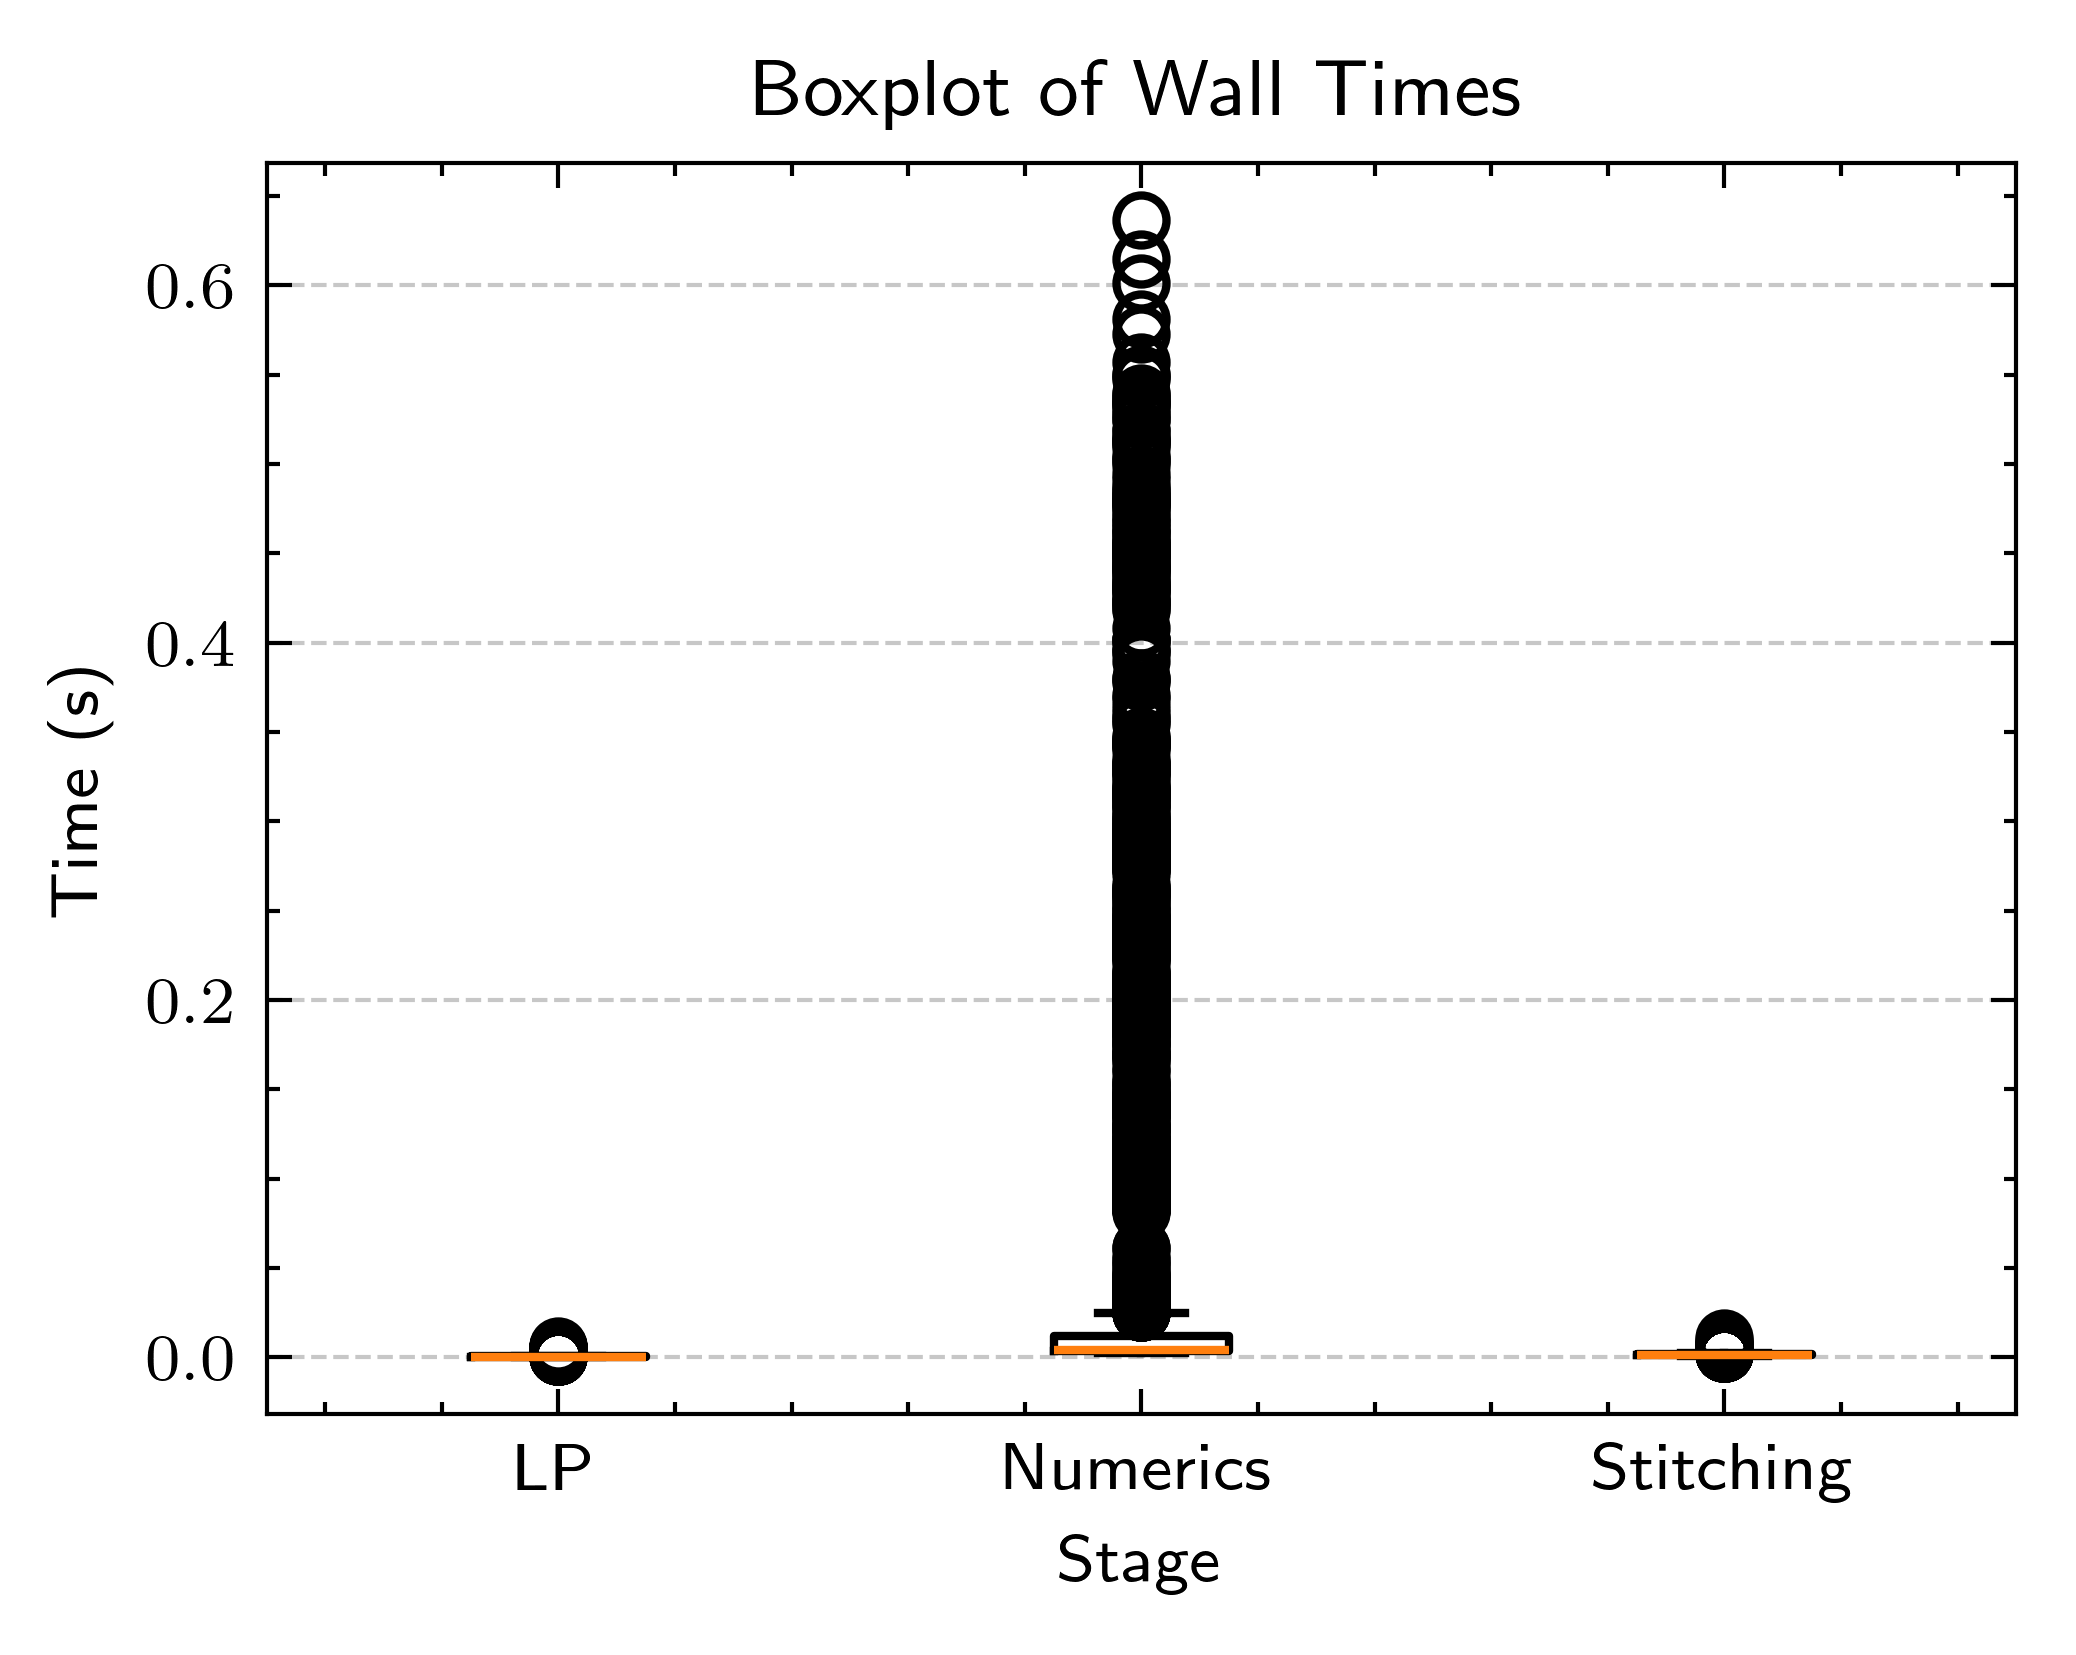

In [118]:
import scienceplots
import lovelyplots

import matplotlib.pyplot as plt
import numpy as np

# Convert list of dicts to lists of values
lp_times = [d["lp"] for d in all_timings]
numeric_times = [d["numeric"] for d in all_timings]
stitch_times = [d["stitch"] for d in all_timings]

# Prepare data for boxplot
data = [lp_times, numeric_times, stitch_times]
labels = ["LP", "Numerics", "Stitching"]

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, figsize=(3.5, 2.8))
    axes.boxplot(data, tick_labels=labels)
    axes.set_xlabel("Stage")
    axes.set_ylabel("Time (s)")
    axes.set_title("Boxplot of Wall Times")
    axes.grid(axis="y", linestyle="--", alpha=0.7)
    fig.tight_layout()
plt.show()

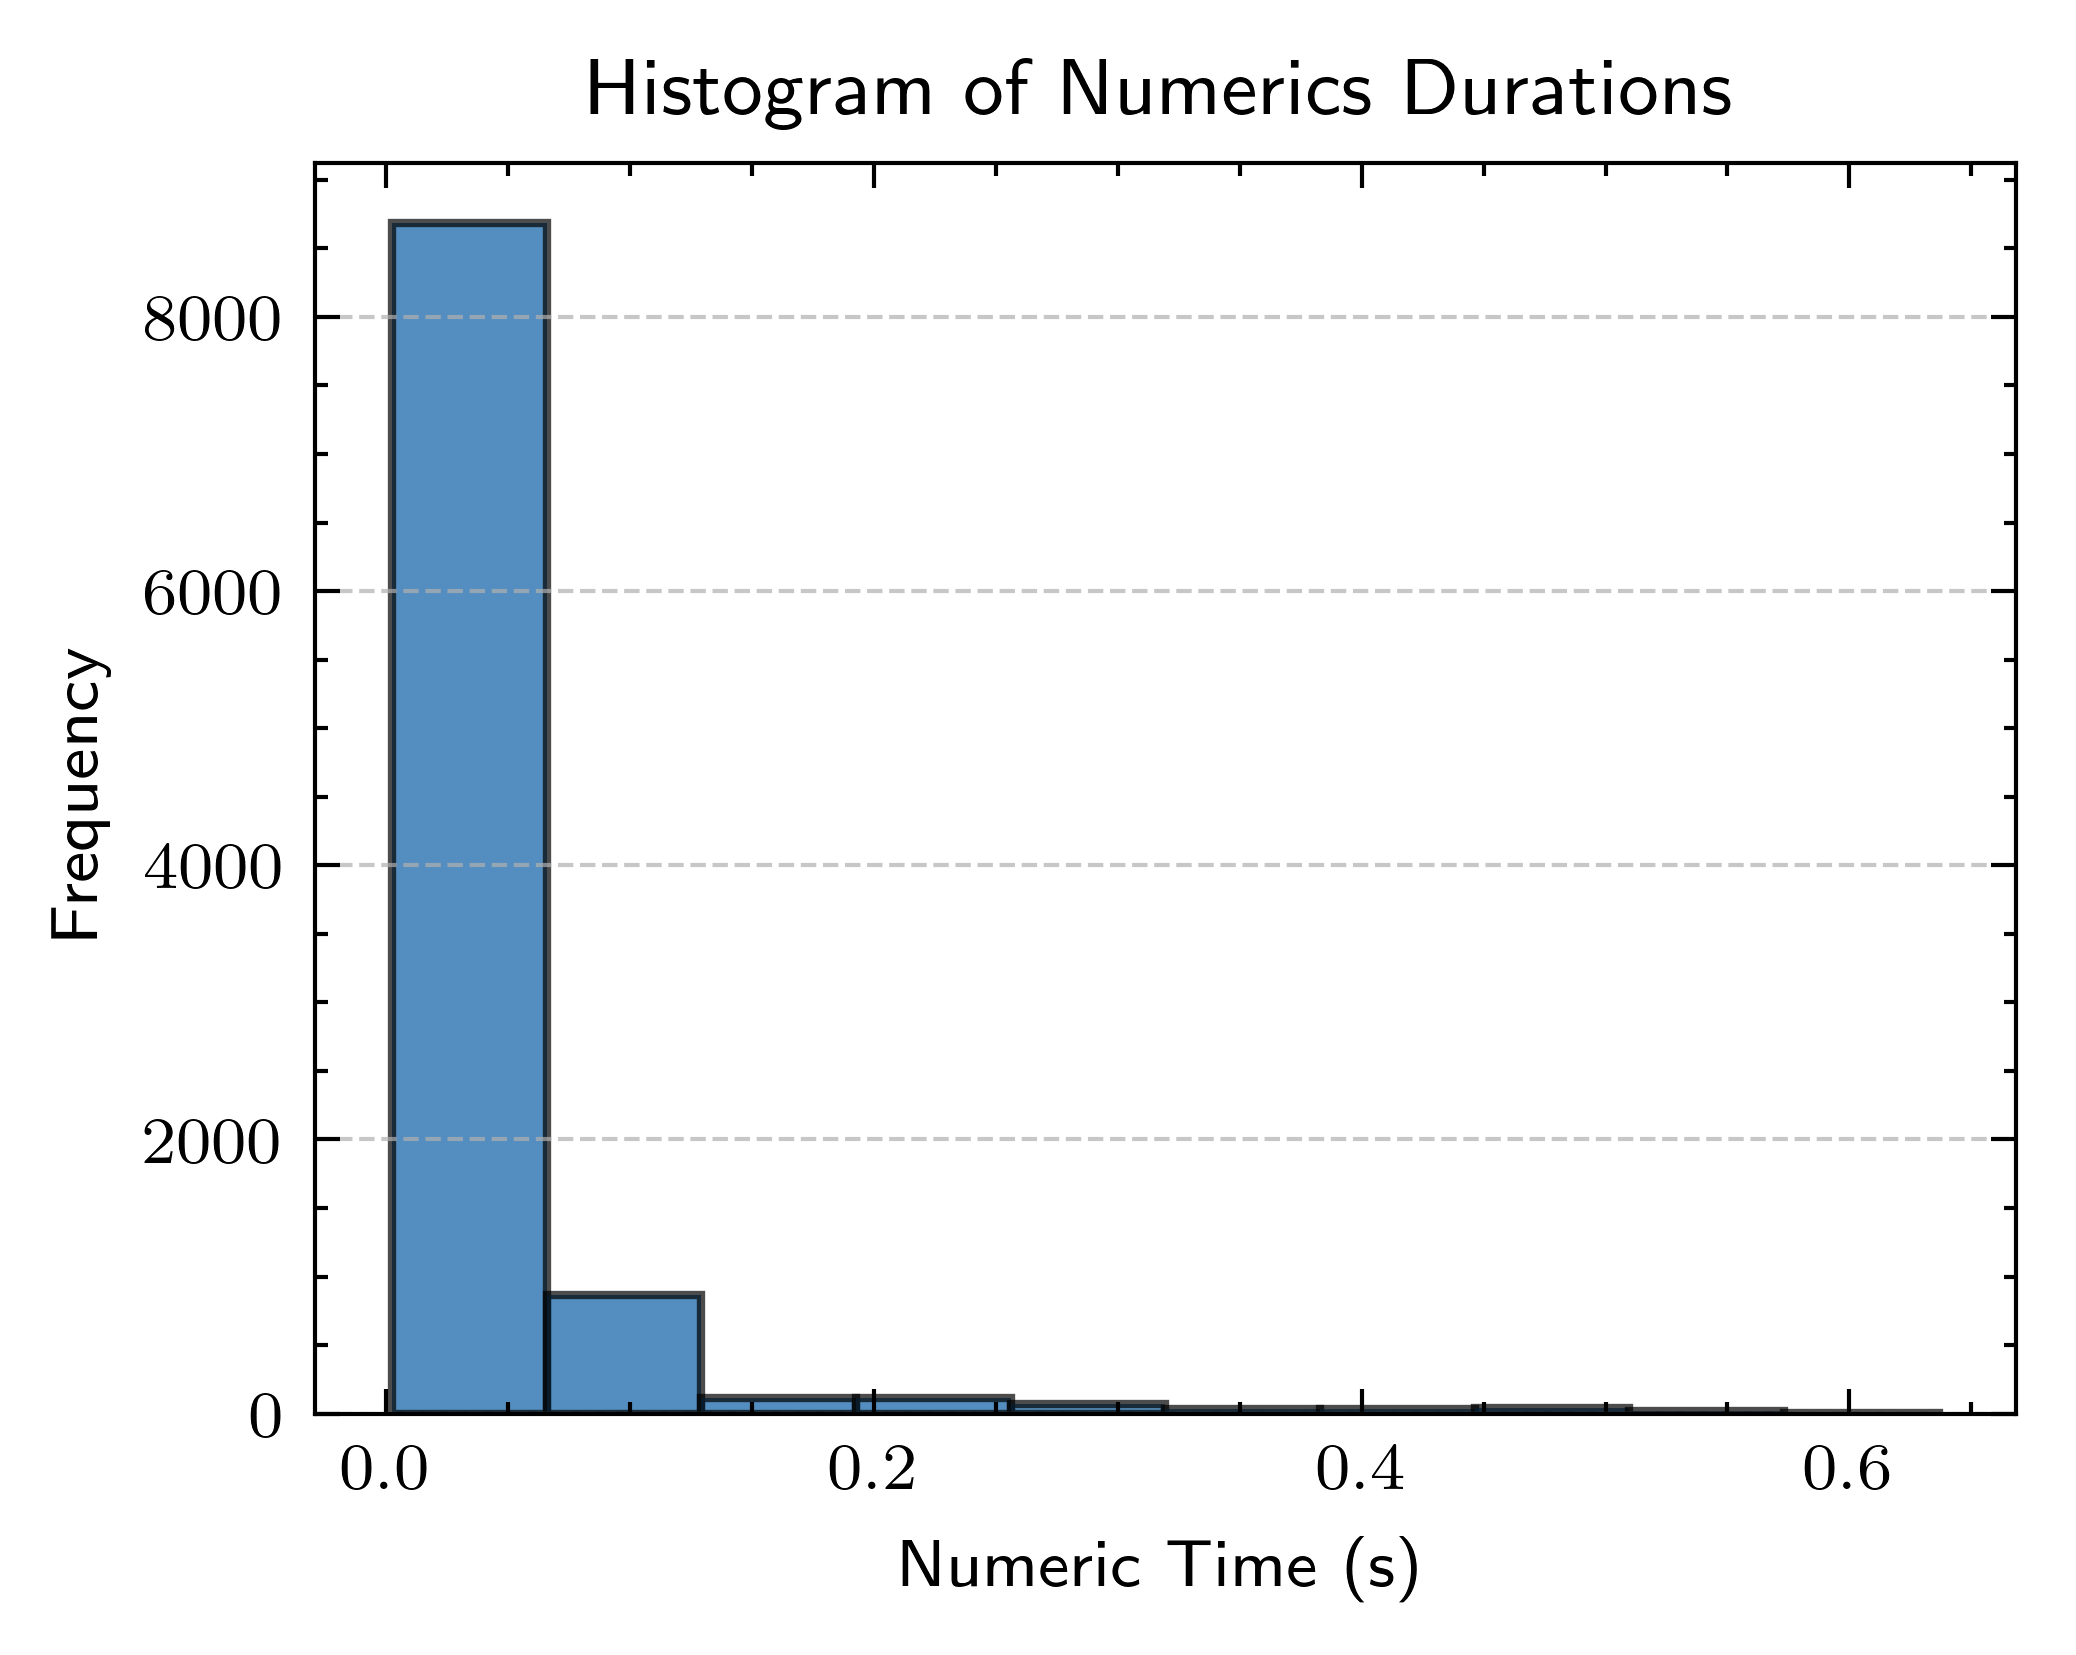

In [112]:
with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, axes = plt.subplots(1, figsize=(3.5, 2.8))
    axes.hist(numeric_times, edgecolor="black", alpha=0.7)
    axes.set_xlabel("Numeric Time (s)")
    axes.set_ylabel("Frequency")
    axes.set_title("Histogram of Numerics Durations")
    axes.grid(axis="y", linestyle="--", alpha=0.7)
    fig.tight_layout()
plt.show()